# EV Purchase Prediction：多样化模型与验证驱动的集成学习

## tl;dr

- 本轮测试了高分辨率浅层 XGBoost、LightGBM GOSS、Extra Trees 和 CatBoost Lossguide，并与上一轮模型统一比较。
- 新候选中最好的是 depth-5、`max_bin=4096` 的 XGBoost，独立留出集 ROC-AUC 为 `0.942993`；仍低于上一轮 `max_bin=8192` 的 `0.943136`。
- depth-3 XGBoost 为 `0.942544`，CatBoost Lossguide 为 `0.941687`，LightGBM GOSS 为 `0.941111`，Extra Trees 为 `0.935314`。
- 对数损失优化融合得到约 98.90% depth-5 XGBoost、1.06% depth-3 XGBoost，其余模型接近零；留出集 AUC 为 `0.942992`，没有超过单模型。
- 排名融合直接退化为 100% depth-5 XGBoost。这是一个重要的负结果：当前候选虽然算法名称不同，但没有提供足够高质量的互补排序。

## Context & Methods

### 目标

验证不同学习机制是否能超过高分辨率 XGBoost，并用独立调优集学习集成权重，避免根据最终留出集人工选择融合比例。

### Key Assumptions

- 所有候选使用与前几轮一致的固定分层训练、调优和留出划分。
- 模型选择和融合权重只使用调优集；留出集仅用于一次最终比较。
- ROC-AUC 关注排序，因此同时测试概率融合和百分位排名融合。
- 上一轮 `max_bin=8192` 的结果来自相同划分，可直接作为历史最佳基准。

## Data

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve().parent
ARTIFACT_DIR = ROOT / "artifacts"
SUBMISSION_DIR = ROOT / "submissions"
TARGET = "Will_Buy_EV"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.titleweight"] = "bold"

results = pd.read_csv(ARTIFACT_DIR / "diverse_model_comparison.csv")
with open(ARTIFACT_DIR / "diverse_ensemble_weights.json", encoding="utf-8") as file:
    weights = json.load(file)

results

,Model,Best_Iteration,Fit_Seconds,Tuning_ROC_AUC,Tuning_Log_Loss,Tuning_Average_Precision,Holdout_ROC_AUC,Holdout_Log_Loss,Holdout_Average_Precision
0,XGBoost_FineBin_Depth5,1799.0,65.713408,0.942951,0.224449,0.763260,0.942993,0.224261,0.764391
1,Ensemble_Rank_Forward,NaN,NaN,0.942951,0.598387,0.763260,0.942993,0.598136,0.764391
2,Ensemble_LogLoss_Optimized,NaN,NaN,0.942948,0.224454,0.763243,0.942992,0.224264,0.764378
3,XGBoost_FineBin_Depth3,2798.0,89.423961,0.942390,0.225531,0.760777,0.942544,0.225133,0.761954
4,CatBoost_Lossguide,1184.0,443.923954,0.941822,0.226711,0.757635,0.941687,0.226738,0.757765
5,LightGBM_GOSS,593.0,14.666387,0.940671,0.228564,0.755046,0.941111,0.227701,0.755605
6,ExtraTrees,NaN,191.508726,0.934917,0.267520,0.736897,0.935314,0.262895,0.736445


## Results

### 1. 新模型与历史最佳比较

In [2]:
historical_rows = pd.DataFrame({
    "Model": [
        "Previous_XGBoost_MaxBin8192",
        "Previous_Refined_XGBoost",
        "Previous_PyTorch_Embedding",
    ],
    "Holdout_ROC_AUC": [0.9431355182, 0.9418548562, 0.938041],
    "Source": ["Previous", "Previous", "Previous"],
})
current_rows = results[["Model", "Holdout_ROC_AUC"]].copy()
current_rows["Source"] = "Current"
comparison = pd.concat([historical_rows, current_rows], ignore_index=True)
comparison.sort_values("Holdout_ROC_AUC", ascending=False)

,Model,Holdout_ROC_AUC,Source
0,Previous_XGBoost_MaxBin8192,0.943136,Previous
3,XGBoost_FineBin_Depth5,0.942993,Current
4,Ensemble_Rank_Forward,0.942993,Current
5,Ensemble_LogLoss_Optimized,0.942992,Current
6,XGBoost_FineBin_Depth3,0.942544,Current
1,Previous_Refined_XGBoost,0.941855,Previous
7,CatBoost_Lossguide,0.941687,Current
8,LightGBM_GOSS,0.941111,Current
2,Previous_PyTorch_Embedding,0.938041,Previous
9,ExtraTrees,0.935314,Current


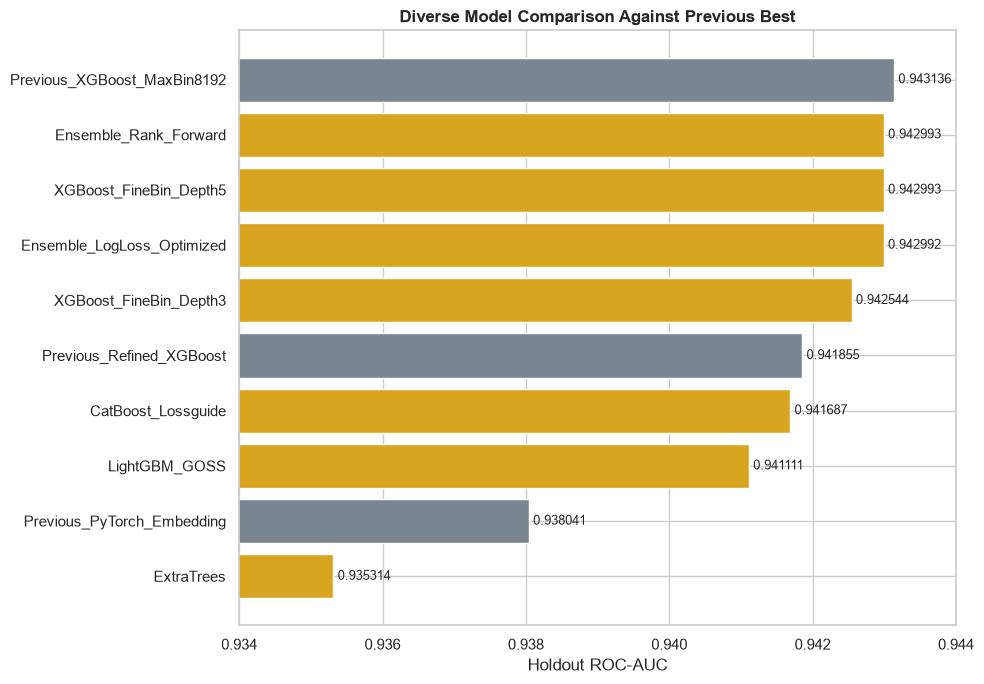

In [3]:
plot_data = comparison.sort_values("Holdout_ROC_AUC")
colors = plot_data["Source"].map({"Previous": "#7A8793", "Current": "#D9A520"})
fig, axis = plt.subplots(figsize=(10, 7))
axis.barh(plot_data["Model"], plot_data["Holdout_ROC_AUC"], color=colors)
axis.set_xlim(0.934, 0.944)
axis.set_xlabel("Holdout ROC-AUC")
axis.set_title("Diverse Model Comparison Against Previous Best")
for index, value in enumerate(plot_data["Holdout_ROC_AUC"]):
    axis.text(value + 0.00006, index, f"{value:.6f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

高分辨率 XGBoost 仍然领先。较浅的树保留了大部分性能，但没有形成更好的单模型；GOSS、Lossguide 和完全随机切分都没有改善主排序。

### 2. 精度与训练成本

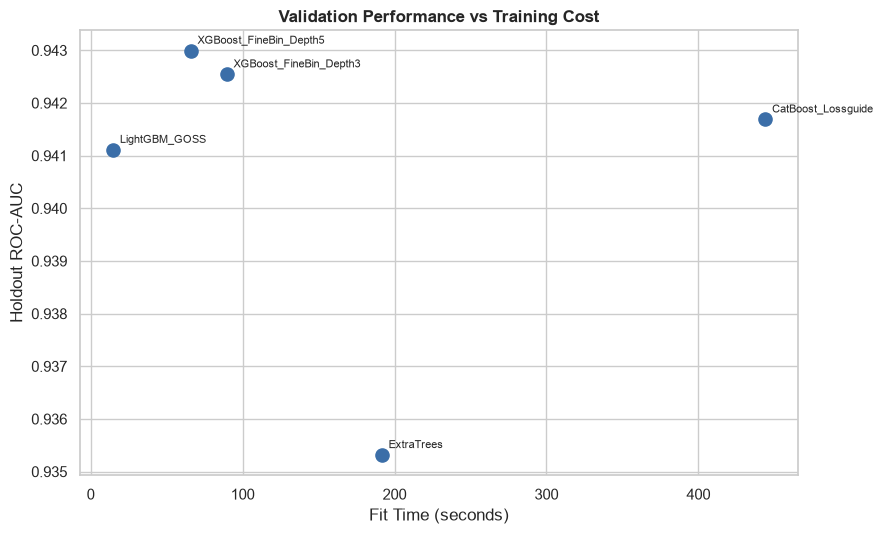

In [4]:
base_models = results[results["Fit_Seconds"].notna()].copy()
fig, axis = plt.subplots(figsize=(9, 5.5))
axis.scatter(
    base_models["Fit_Seconds"],
    base_models["Holdout_ROC_AUC"],
    s=90,
    color="#3B6EA8",
)
for _, row in base_models.iterrows():
    axis.annotate(
        row["Model"],
        (row["Fit_Seconds"], row["Holdout_ROC_AUC"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )
axis.set_xlabel("Fit Time (seconds)")
axis.set_ylabel("Holdout ROC-AUC")
axis.set_title("Validation Performance vs Training Cost")
plt.tight_layout()
plt.show()

LightGBM GOSS 很快，但精度不足；CatBoost Lossguide 和 Extra Trees 的计算成本较高，却仍明显落后。depth-5 XGBoost 同时提供最高精度和较好的成本效率。

### 3. 概率融合权重

In [5]:
weight_table = pd.DataFrame({
    "Model": weights["models"],
    "LogLoss_Weight": [weights["logloss_weights"][name] for name in weights["models"]],
    "Rank_Weight": [weights["rank_weights"][name] for name in weights["models"]],
}).sort_values("LogLoss_Weight", ascending=False)
weight_table

,Model,LogLoss_Weight,Rank_Weight
0,XGBoost_FineBin_Depth5,9.889806e-01,1.0
1,XGBoost_FineBin_Depth3,1.062325e-02,0.0
4,CatBoost_Lossguide,3.949973e-04,0.0
2,LightGBM_GOSS,1.180217e-06,0.0
3,ExtraTrees,2.648403e-11,0.0


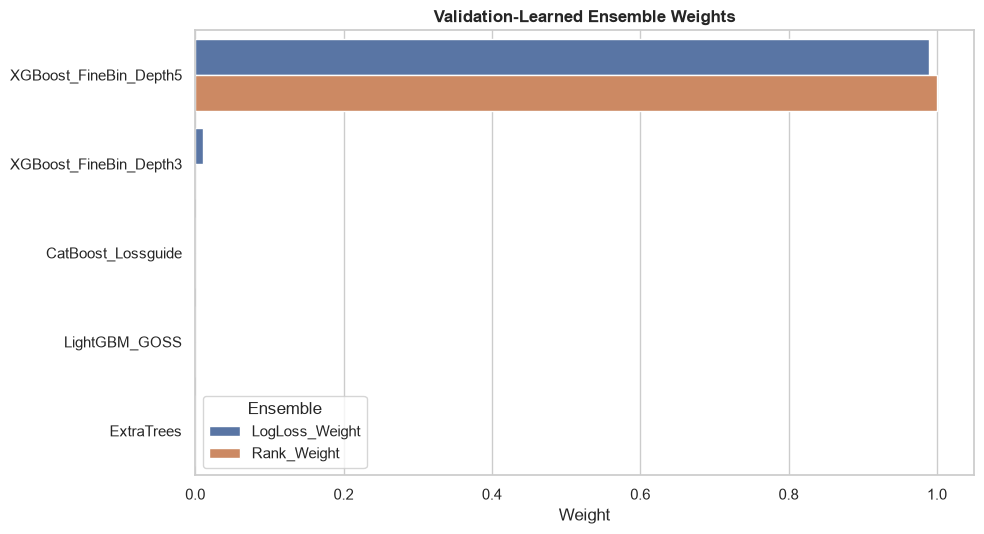

In [6]:
weight_long = weight_table.melt(
    id_vars="Model",
    value_vars=["LogLoss_Weight", "Rank_Weight"],
    var_name="Ensemble",
    value_name="Weight",
)
fig, axis = plt.subplots(figsize=(10, 5.5))
sns.barplot(data=weight_long, y="Model", x="Weight", hue="Ensemble", ax=axis)
axis.set_title("Validation-Learned Ensemble Weights")
axis.set_xlabel("Weight")
axis.set_ylabel("")
plt.tight_layout()
plt.show()

优化器几乎拒绝所有弱模型。概率融合只给 depth-3 约 1% 权重，排名融合完全不加入其他模型；这比手工等权融合更可靠地说明当前没有可用的互补增益。

### 4. 集成结果

In [7]:
ensemble_comparison = results[
    results["Model"].isin([
        "XGBoost_FineBin_Depth5",
        "Ensemble_LogLoss_Optimized",
        "Ensemble_Rank_Forward",
    ])
][[
    "Model",
    "Tuning_ROC_AUC",
    "Holdout_ROC_AUC",
    "Holdout_Log_Loss",
    "Holdout_Average_Precision",
]].sort_values("Holdout_ROC_AUC", ascending=False)
ensemble_comparison

,Model,Tuning_ROC_AUC,Holdout_ROC_AUC,Holdout_Log_Loss,Holdout_Average_Precision
0,XGBoost_FineBin_Depth5,0.942951,0.942993,0.224261,0.764391
1,Ensemble_Rank_Forward,0.942951,0.942993,0.598136,0.764391
2,Ensemble_LogLoss_Optimized,0.942948,0.942992,0.224264,0.764378


两个融合方案都没有超过单模型。对数损失融合的留出集 AUC 仅比 depth-5 单模型低约 `0.000001`，本质上与单模型相同；排名融合则完全等同于单模型。

### 5. 实验提交文件相关性

In [8]:
submission_files = {
    "Depth5_4096_Ensemble": "submission_xgboost_finebin_4096_seed_ensemble.csv",
    "Depth3_4096": "submission_xgboost_finebin_depth3_seed_42.csv",
    "Validated_99_01": "submission_validated_depth_ensemble_99_01.csv",
    "Previous_8192": "submission_xgboost_finebin_8192_seed_42.csv",
}
submission_predictions = pd.DataFrame({
    name: pd.read_csv(SUBMISSION_DIR / filename)[TARGET]
    for name, filename in submission_files.items()
})
correlation = submission_predictions.corr(method="spearman")
correlation

,Depth5_4096_Ensemble,Depth3_4096,Validated_99_01,Previous_8192
Depth5_4096_Ensemble,1.000000,0.998083,1.000000,0.999745
Depth3_4096,0.998083,1.000000,0.998129,0.997993
Validated_99_01,1.000000,0.998129,1.000000,0.999747
Previous_8192,0.999745,0.997993,0.999747,1.000000


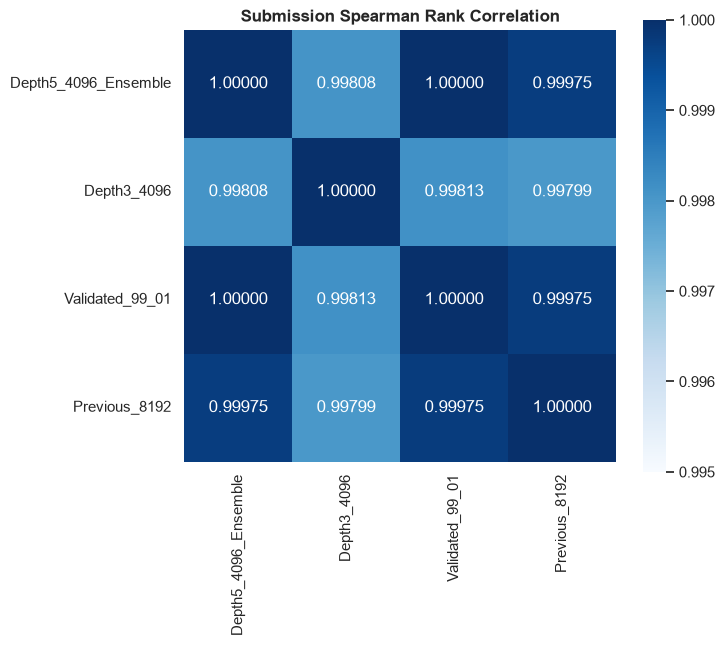

In [9]:
fig, axis = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".5f",
    cmap="Blues",
    vmin=0.995,
    vmax=1.0,
    square=True,
    ax=axis,
)
axis.set_title("Submission Spearman Rank Correlation")
plt.tight_layout()
plt.show()

## Takeaways

### 推荐结论

1. 继续把上一轮 `submission_xgboost_finebin_8192_seed_42.csv` 作为首选，它仍是本地最佳模型。
2. `submission_validated_depth_ensemble_99_01.csv` 是本轮新的保守融合实验文件，但本地没有超过 depth-5 单模型，只建议在有额外提交额度时测试。
3. 不建议为当前 LightGBM GOSS、Extra Trees 或 CatBoost Lossguide 生成全量提交，它们的验证精度和权重都不支持这样做。

### 方法论结论

- 集成的关键不是模型数量，而是高质量且不完全相关的误差。
- 当权重优化和排名前向选择都退化到单模型时，继续手工增加弱模型通常只会降低成绩。
- 下一步若要继续突破，应寻找真正不同且足够强的模型，例如专门的现代深度表格架构或软树模型；这可能需要安装新的依赖，安装前应先确认。

### Reproducible artifacts

- `compare_diverse_ensembles.py`
- `train_validated_depth_ensemble.py`
- `artifacts/diverse_model_comparison.csv`
- `artifacts/diverse_ensemble_weights.json`